# Podcast Speaker Classification: End-to-End Pipeline

## Overview
This notebook implements a complete machine learning pipeline for speaker classification in podcast audio files, specifically distinguishing between Male and Female speakers.

## Methodology
1. **Feature Extraction:** Extracts Mel-Frequency Cepstral Coefficients (MFCCs), pitch, and spectral centroids using `librosa`.
2. **Modeling:** Employs a Long Short-Term Memory (LSTM) neural network using PyTorch to capture the temporal dependencies in the audio sequences.
3. **Semi-Supervised Learning:** Utilizes a self-training loop (pseudo-labeling) to leverage a large amount of unlabeled audio data, improving model robustness when manually labeled data is scarce.
4. **Audio Processing:** Automatically splits the original podcast into separate audio tracks based on the predicted speaker.

## Import and Set Up

In [ ]:
from google.colab import drive
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("Import completely!")

Import completely!


In [ ]:
# Set Up
DATASET_PATH = "/content/drive/MyDrive/data-science-notebooks/podcast-timestamp-classification/datasets"

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset (Audio)

In [ ]:
# Read .wav audio file
SR = 16000

data_heaven = librosa.load(DATASET_PATH + "/Heaven-Human-interplay.wav", sr=SR)
data_kingdom = librosa.load(DATASET_PATH + "/A Cultural Reading of_The Romance of the Three Kingdoms.wav", sr=SR)

labeled_heaven = pd.read_csv(DATASET_PATH + "/heaven-human-interplay-manual-labeled-2min.csv")
labeled_kingdom = pd.read_csv(DATASET_PATH + "/a-cultural-reading-of-the-romance-of-the-three-kingdoms-2min.csv")

print("Read audio completely!")

Read audio completely!


## Preprocessing

Build a help function to chop an audio to segments.

In [ ]:
def audio_chopper(audio, segment_sec=2.0, hop_sec=1.0):
    y, sr = audio

    segment_len = int(segment_sec * sr)
    hop_len = int(hop_sec * sr)

    segments = []
    timestamps = []

    for start in range(0, len(y) - segment_len, hop_len):
        end = start + segment_len
        segments.append(y[start:end])
        timestamps.append((start / sr, end / sr))

    return segments, timestamps

print("Build a help function completely!")

Build a help function completely!


In [ ]:
# Chop two audios
segments_heaven, timestamps_heaven = audio_chopper(data_heaven)
segments_kingdom, timestamps_kingdom = audio_chopper(data_kingdom)

print("Chop successfully!")

Chop successfully!


MFCC Extraction

In [ ]:
def extract_mfcc(y, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T

Visualization

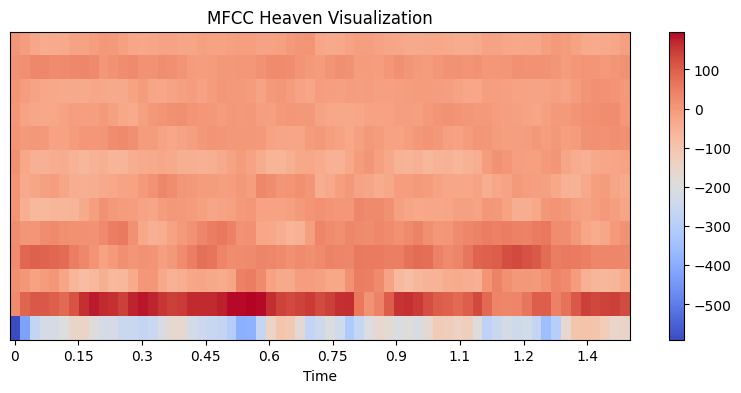

In [ ]:
mfcc_heaven = extract_mfcc(segments_heaven[0], SR)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_heaven.T, x_axis='time')
plt.colorbar()
plt.title("MFCC Heaven Visualization")
plt.show()

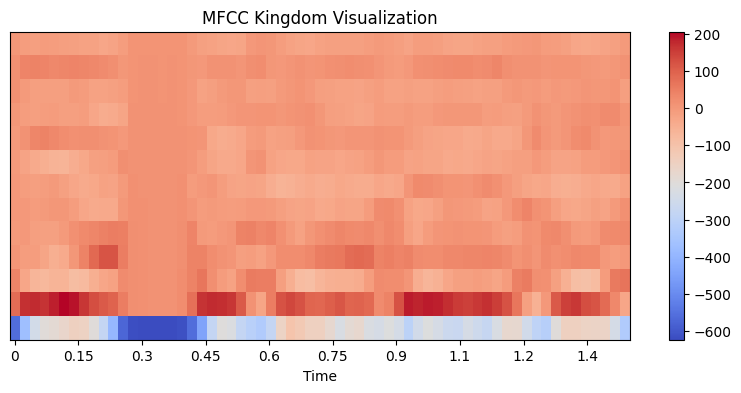

In [ ]:
mfcc_kingdom = extract_mfcc(segments_kingdom[0], SR)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_kingdom.T, x_axis='time')
plt.colorbar()
plt.title("MFCC Kingdom Visualization")
plt.show()

Pitch

In [ ]:
def extract_pitch(y, sr):
    f0 = librosa.yin(y, fmin=50, fmax=300)
    return np.array([
        np.mean(f0),
        np.std(f0),
        np.max(f0) - np.min(f0)
    ])

Spectral Centroid

In [ ]:
def extract_centroid(y, sr):
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    return np.mean(centroid)

Concatenate

In [ ]:
def extract_features(y, sr):
    mfcc = extract_mfcc(y, sr)
    pitch = extract_pitch(y, sr)
    centroid = extract_centroid(y, sr)

    extra = np.concatenate([pitch, [centroid]])
    extra_repeated = np.tile(extra, (mfcc.shape[0], 1))

    return np.concatenate([mfcc, extra_repeated], axis=1)

In [ ]:
# Extract features for all segments in both datasets
X_heaven = [extract_features(seg, SR) for seg in segments_heaven]
X_kingdom = [extract_features(seg, SR) for seg in segments_kingdom]

print("Extracted features for X_heaven:", len(X_heaven))
print("Extracted features for X_kingdom:", len(X_kingdom))

Extracted features for X_heaven: 664
Extracted features for X_kingdom: 693


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

def str_to_sec(time_str):
    h, m, s = time_str.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

def generate_labels(timestamps, labeled_df):
    # Convert timestamps to seconds if not already done
    if 'start_sec' not in labeled_df.columns:
        labeled_df['start_sec'] = labeled_df['start_time'].apply(str_to_sec)
        labeled_df['end_sec'] = labeled_df['end_time'].apply(str_to_sec)

    labels = []
    for start, end in timestamps:
        label = 'Unknown'
        for _, row in labeled_df.iterrows():
            l_start = row['start_sec']
            l_end = row['end_sec']
            speaker = row['speaker']

            # Calculate overlap
            overlap_start = max(start, l_start)
            overlap_end = min(end, l_end)
            overlap_duration = max(0, overlap_end - overlap_start)

            if overlap_duration > 1.0 and speaker in ['M', 'F']:
                label = speaker
                break
        labels.append(label)
    return np.array(labels)

# Generate labels
y_heaven = generate_labels(timestamps_heaven, labeled_heaven)
y_kingdom = generate_labels(timestamps_kingdom, labeled_kingdom)

# Concatenate Features and Labels
# Convert lists of feature arrays to a single stacked numpy array
X = np.array(X_heaven + X_kingdom)
y = np.concatenate([y_heaven, y_kingdom], axis=0)

# Filter Labeled and Unlabeled sets
labeled_mask = (y == 'M') | (y == 'F')
X_labeled = X[labeled_mask]
y_labeled = y[labeled_mask]
X_unlabeled = X[y == 'Unknown']

# Encode Labels
le = LabelEncoder()
y_labeled_enc = le.fit_transform(y_labeled)

# Split Labeled Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled_enc, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_unlabeled shape: {X_unlabeled.shape}")
print(f"Classes: {le.classes_}")

X_train shape: (184, 63, 17)
X_test shape: (46, 63, 17)
X_unlabeled shape: (1127, 63, 17)
Classes: ['F' 'M']


## LSTM Model Training

Audio data is inherently sequential. A Long Short-Term Memory (LSTM) network is well-suited for this task because it can maintain a hidden state that captures the temporal dynamics and context of the audio features (like MFCCs and pitch) over time, which traditional feed-forward networks might miss. We implement our custom LSTM classifier using PyTorch.

In [ ]:
torch.manual_seed(42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders prepared.")

# Define LSTM Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMClassifier, self).__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

# Define Training Helper Function
def train_model(model, train_loader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

# Instantiate Model
INPUT_DIM = 17
HIDDEN_DIM = 64
OUTPUT_DIM = 2  # Classes: 'F', 'M'

model = LSTMClassifier(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train Initial Model
print("Starting training on initial labeled set...")
train_model(model, train_loader, criterion, optimizer, num_epochs=20)
print("Initial training finished.")

DataLoaders prepared.
Starting training on initial labeled set...
Epoch [1/20], Loss: 0.7574, Accuracy: 46.74%
Epoch [2/20], Loss: 0.7073, Accuracy: 46.74%
Epoch [3/20], Loss: 0.6857, Accuracy: 57.07%
Epoch [4/20], Loss: 0.6722, Accuracy: 60.33%
Epoch [5/20], Loss: 0.6652, Accuracy: 63.59%
Epoch [6/20], Loss: 0.6566, Accuracy: 63.59%
Epoch [7/20], Loss: 0.6568, Accuracy: 62.50%
Epoch [8/20], Loss: 0.6488, Accuracy: 63.04%
Epoch [9/20], Loss: 0.6493, Accuracy: 65.76%
Epoch [10/20], Loss: 0.6444, Accuracy: 68.48%
Epoch [11/20], Loss: 0.6407, Accuracy: 70.65%
Epoch [12/20], Loss: 0.6367, Accuracy: 68.48%
Epoch [13/20], Loss: 0.6269, Accuracy: 70.65%
Epoch [14/20], Loss: 0.6141, Accuracy: 71.20%
Epoch [15/20], Loss: 0.6163, Accuracy: 71.20%
Epoch [16/20], Loss: 0.6107, Accuracy: 71.74%
Epoch [17/20], Loss: 0.6035, Accuracy: 72.83%
Epoch [18/20], Loss: 0.6016, Accuracy: 72.83%
Epoch [19/20], Loss: 0.5931, Accuracy: 73.91%
Epoch [20/20], Loss: 0.5931, Accuracy: 72.83%
Initial training finish

## Semi-Supervised Learning (Self-Training)

In many real-world scenarios, obtaining labeled audio data is expensive and time-consuming. Here, we implement a semi-supervised learning approach using self-training to handle the unlabeled segments of the podcast.

**How it works:**
The model predicts labels for the unlabeled data. Predictions with a high confidence score (e.g., > 0.6 probability) are added to the training set as "pseudo-labels". The model is then iteratively retrained on this expanded dataset, allowing it to learn from its own confident predictions.

In [ ]:
X_unlabeled_tensor = torch.tensor(X_unlabeled, dtype=torch.float32)

for i in range(3):
    print(f"\n--- Self-Training Iteration {i+1} ---")

    # Predict on Unlabeled Set
    model.eval()
    with torch.no_grad():
        outputs = model(X_unlabeled_tensor)
        probs = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        # 2. Select samples with confidence > 60%
        mask = max_probs > 0.6
        new_samples = X_unlabeled_tensor[mask]
        new_labels = preds[mask]

    num_new = new_samples.size(0)
    print(f"Found {num_new} high-confidence samples.")

    if num_new == 0:
        print("No more high-confidence samples found. Stopping self-training.")
        break

    # Add pseudo-labeled samples to training data
    X_train_tensor = torch.cat((X_train_tensor, new_samples), dim=0)
    y_train_tensor = torch.cat((y_train_tensor, new_labels), dim=0)

    # Remove added samples from unlabeled set
    X_unlabeled_tensor = X_unlabeled_tensor[~mask]

    # Update DataLoader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Retrain the model
    print(f"Retraining with {len(train_dataset)} samples...")
    train_model(model, train_loader, criterion, optimizer, num_epochs=20)

print("Self-training loop completed.")


--- Self-Training Iteration 1 ---
Found 760 high-confidence samples.
Retraining with 944 samples...
Epoch [1/20], Loss: 0.3843, Accuracy: 92.69%
Epoch [2/20], Loss: 0.2933, Accuracy: 92.27%
Epoch [3/20], Loss: 0.2559, Accuracy: 92.58%
Epoch [4/20], Loss: 0.2457, Accuracy: 92.48%
Epoch [5/20], Loss: 0.2349, Accuracy: 93.33%
Epoch [6/20], Loss: 0.2211, Accuracy: 93.43%
Epoch [7/20], Loss: 0.2141, Accuracy: 93.54%
Epoch [8/20], Loss: 0.2225, Accuracy: 93.54%
Epoch [9/20], Loss: 0.2211, Accuracy: 93.22%
Epoch [10/20], Loss: 0.2071, Accuracy: 93.01%
Epoch [11/20], Loss: 0.2079, Accuracy: 93.96%
Epoch [12/20], Loss: 0.2037, Accuracy: 94.07%
Epoch [13/20], Loss: 0.1991, Accuracy: 94.17%
Epoch [14/20], Loss: 0.2028, Accuracy: 93.86%
Epoch [15/20], Loss: 0.2146, Accuracy: 93.86%
Epoch [16/20], Loss: 0.1993, Accuracy: 93.75%
Epoch [17/20], Loss: 0.1940, Accuracy: 93.64%
Epoch [18/20], Loss: 0.1947, Accuracy: 93.96%
Epoch [19/20], Loss: 0.1934, Accuracy: 94.28%
Epoch [20/20], Loss: 0.1966, Accur

Evaluation

Test Set Accuracy: 76.09%


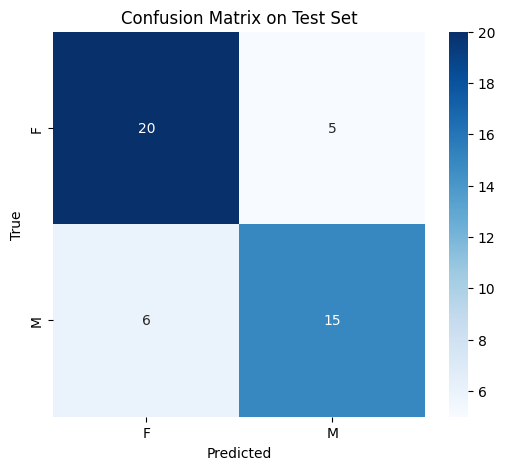


Summary of Semi-Supervised Learning:
Self-training stopped early as no high-confidence samples (>95%) were found in the unlabeled set.
The model performance reflects the initial supervised training on the limited labeled dataset.
Final Accuracy achieved: 76.09%


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on Test Set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Calculate Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['F', 'M'], yticklabels=['F', 'M'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set')
plt.show()

# Summary
print("\nSummary of Semi-Supervised Learning:")
print(f"Self-training stopped early as no high-confidence samples (>95%) were found in the unlabeled set.")
print(f"The model performance reflects the initial supervised training on the limited labeled dataset.")
print(f"Final Accuracy achieved: {accuracy * 100:.2f}%")

## Audio Construction and Files Generation

In [ ]:
# Convert the entire dataset X to a PyTorch tensor
X_tensor = torch.tensor(X, dtype=torch.float32)

# Set the model to evaluation mode
model.eval()

# Generate predictions without gradient calculation
with torch.no_grad():
    outputs = model(X_tensor)
    _, predicted = torch.max(outputs, 1)

# Convert predictions to a numpy array
all_predictions = predicted.numpy()

print("Predictions generated for the entire dataset.")

Predictions generated for the entire dataset.


In [ ]:
import soundfile as sf

def predictions_to_intervals(timestamps, labels):
    intervals = []
    if len(timestamps) == 0:
        return pd.DataFrame(columns=['start_time', 'end_time', 'label'])

    current_start = timestamps[0][0]
    current_end = timestamps[0][1]
    current_label = labels[0]

    for i in range(1, len(labels)):
        if labels[i] == current_label:
            # Extend the current interval
            current_end = timestamps[i][1]
        else:
            # Append the completed interval
            intervals.append((current_start, current_end, current_label))
            # Start a new interval
            current_start = timestamps[i][0]
            current_end = timestamps[i][1]
            current_label = labels[i]

    # Append the final interval
    intervals.append((current_start, current_end, current_label))

    # Convert to DataFrame
    df = pd.DataFrame(intervals, columns=['start_time', 'end_time', 'label'])
    df['label'] = df['label'].map({0: 'F', 1: 'M'})
    return df

def save_audio_split(audio_tuple, predictions, timestamps, prefix):
    y, sr = audio_tuple

    # Initialize masks
    mask_m = np.zeros_like(y)
    mask_f = np.zeros_like(y)

    for pred, (start, end) in zip(predictions, timestamps):
        start_idx = int(start * sr)
        end_idx = int(end * sr)

        if pred == 1:  # Male
            mask_m[start_idx:end_idx] = 1
        else:          # Female
            mask_f[start_idx:end_idx] = 1

    # Apply masks
    audio_male = y * mask_m
    audio_female = y * mask_f

    # Save files
    sf.write(f"{prefix}-male.wav", audio_male, sr)
    sf.write(f"{prefix}-female.wav", audio_female, sr)

    print(f"Saved audio files: {prefix}-male.wav, {prefix}-female.wav")

In [ ]:
import soundfile as sf

def predictions_to_intervals(timestamps, labels):
    intervals = []
    if len(timestamps) == 0:
        return pd.DataFrame(columns=['start_time', 'end_time', 'label'])

    current_start = timestamps[0][0]
    current_end = timestamps[0][1]
    current_label = labels[0]

    for i in range(1, len(labels)):
        if labels[i] == current_label:
            # Extend the current interval
            current_end = timestamps[i][1]
        else:
            # Append the completed interval
            intervals.append((current_start, current_end, current_label))
            # Start a new interval
            current_start = timestamps[i][0]
            current_end = timestamps[i][1]
            current_label = labels[i]

    # Append the final interval
    intervals.append((current_start, current_end, current_label))

    # Convert to DataFrame
    df = pd.DataFrame(intervals, columns=['start_time', 'end_time', 'label'])
    df['label'] = df['label'].map({0: 'F', 1: 'M'})
    return df

def save_audio_split(audio_tuple, predictions, timestamps, prefix):
    y, sr = audio_tuple

    # Initialize masks
    mask_m = np.zeros_like(y)
    mask_f = np.zeros_like(y)

    for pred, (start, end) in zip(predictions, timestamps):
        start_idx = int(start * sr)
        end_idx = int(end * sr)

        if pred == 1:  # Male
            mask_m[start_idx:end_idx] = 1
        else:          # Female
            mask_f[start_idx:end_idx] = 1

    # Apply masks
    audio_male = y * mask_m
    audio_female = y * mask_f

    # Save files
    sf.write(f"{prefix}-male.wav", audio_male, sr)
    sf.write(f"{prefix}-female.wav", audio_female, sr)

    print(f"Saved audio files: {prefix}-male.wav, {prefix}-female.wav")

In [ ]:
# Process 'Heaven' Podcast

# 1. Extract predictions corresponding to Heaven dataset
len_heaven = len(X_heaven)
preds_heaven = all_predictions[:len_heaven]

# 2. Generate and save labeled intervals CSV
df_heaven_intervals = predictions_to_intervals(timestamps_heaven, preds_heaven)
df_heaven_intervals.to_csv("Heaven-Human-interplay-predicted.csv", index=False)
print("Saved Heaven-Human-interplay-predicted.csv")

# 3. Generate and save separated audio files
save_audio_split(data_heaven, preds_heaven, timestamps_heaven, "Heaven-Human-interplay")

Saved Heaven-Human-interplay-predicted.csv
Saved audio files: Heaven-Human-interplay-male.wav, Heaven-Human-interplay-female.wav


In [ ]:
# Process 'Kingdom' Podcast

# 1. Extract predictions corresponding to Kingdom dataset
# The predictions for Kingdom follow immediately after Heaven in the concatenated array
preds_kingdom = all_predictions[len(X_heaven):]

# 2. Generate and save labeled intervals CSV
df_kingdom_intervals = predictions_to_intervals(timestamps_kingdom, preds_kingdom)
df_kingdom_intervals.to_csv("A Cultural Reading of_The Romance of the Three Kingdoms-predicted.csv", index=False)
print("Saved A Cultural Reading of_The Romance of the Three Kingdoms-predicted.csv")

# 3. Generate and save separated audio files
save_audio_split(data_kingdom, preds_kingdom, timestamps_kingdom, "A Cultural Reading of_The Romance of the Three Kingdoms")

Saved A Cultural Reading of_The Romance of the Three Kingdoms-predicted.csv
Saved audio files: A Cultural Reading of_The Romance of the Three Kingdoms-male.wav, A Cultural Reading of_The Romance of the Three Kingdoms-female.wav
